# Text-to-Speech Evaluation

This notebook evaluates already generated audio files. It expects WAV files under `outputs/{model_name}/{prompt_id}.wav`, for example `outputs/Bark/ancient_wizard.wav`.

It does not load or rerun any text-to-speech generation models.

## 1. Configuration

In [6]:
from pathlib import Path
import os
import json
import warnings

OUTPUT_DIR = Path('outputs')
PROMPTS_PATH = Path('prompts.json')
EVAL_DIR = OUTPUT_DIR / 'evaluation'
NUMBA_CACHE_DIR = OUTPUT_DIR / 'numba_cache'

EVAL_DIR.mkdir(parents=True, exist_ok=True)
NUMBA_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('NUMBA_CACHE_DIR', str(NUMBA_CACHE_DIR))

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Audio, Image, display

warnings.filterwarnings('ignore')

MODEL_NAMES = ['AudioLDM2', 'Bark', 'TangoFlux']
TARGET_SR = 16000
RUN_CLAP = True
RUN_UTMOS = True
CLAP_TEXT_MODE = 'combined'


## 2. Load Prompts and Discover Audio

In [7]:
with PROMPTS_PATH.open('r', encoding='utf-8') as f:
    speech_tests = json.load(f)

prompt_lookup = {item['id']: item for item in speech_tests}

def get_clap_text(item):
    if CLAP_TEXT_MODE == 'style':
        return item.get('style', '')
    if CLAP_TEXT_MODE == 'transcript':
        return item.get('transcript', '')
    return f"{item.get('transcript', '')} {item.get('style', '')}".strip()

def discover_audio_files(output_dir, model_names):
    rows = []

    for model_name in model_names:
        model_dir = output_dir / model_name
        if not model_dir.exists():
            print(f'Missing folder: {model_dir}')
            continue

        for wav_path in sorted(model_dir.glob('*.wav')):
            test_id = wav_path.stem
            item = prompt_lookup.get(test_id)
            if item is None:
                print(f'Skipping unknown prompt id: {wav_path}')
                continue

            rows.append({
                'Model': model_name,
                'Test ID': test_id,
                'Category': item.get('category'),
                'Transcript': item.get('transcript'),
                'Style': item.get('style'),
                'CLAP Text': get_clap_text(item),
                'Audio Path': str(wav_path),
            })

    return pd.DataFrame(rows).sort_values(['Model', 'Test ID']).reset_index(drop=True)

generated_df = discover_audio_files(OUTPUT_DIR, MODEL_NAMES)
print(f'Found {len(generated_df)} matched WAV files.')
display(generated_df.head())

generated_df.to_csv(EVAL_DIR / 'generated_audio_index.csv', index=False)

Found 150 matched WAV files.


,Model,Test ID,Category,Transcript,Style,CLAP Text,Audio Path
0,AudioLDM2,alien_hivemind,Fantasy & Sci-Fi,We are many. You cannot resist our collective ...,A voice that sounds simultaneously male and fe...,We are many. You cannot resist our collective ...,outputs\AudioLDM2\alien_hivemind.wav
1,AudioLDM2,ancient_wizard,Fantasy & Sci-Fi,"You seek the dragon's eye? Foolish child, you ...","An elderly male with a crotchety, ancient, hea...","You seek the dragon's eye? Foolish child, you ...",outputs\AudioLDM2\ancient_wizard.wav
2,AudioLDM2,asmr_whisper,Professions & Archetypes,I am going to tap on this glass very gently. L...,"A young woman speaking in an extremely close, ...",I am going to tap on this glass very gently. L...,outputs\AudioLDM2\asmr_whisper.wav
3,AudioLDM2,auctioneer_fast,Extreme Pacing & Cadence,Do I hear fifty? Fifty dollars to the gentlema...,"A male auctioneer speaking at breakneck speed,...",Do I hear fifty? Fifty dollars to the gentlema...,outputs\AudioLDM2\auctioneer_fast.wav
4,AudioLDM2,bored_teen_gamer,Specific Ages,"Bro, he's literally one shot. Just push him. U...","A teenage boy speaking with a nasal, apathetic...","Bro, he's literally one shot. Just push him. U...",outputs\AudioLDM2\bored_teen_gamer.wav


## 3. Audio-Derived Metrics

These metrics are computed directly from the WAV files, so they do not require generation metadata. Inference time and real-time factor cannot be recovered from audio files alone unless you saved timing metadata during generation.

In [8]:
def prepare_audio(audio):
    audio = np.asarray(audio).squeeze()
    if audio.size == 0:
        raise ValueError('Audio array is empty.')
    return audio.astype(np.float32)

def compute_duration(audio, sr):
    return len(audio) / sr

def compute_loudness(audio):
    audio = prepare_audio(audio)
    return float(np.sqrt(np.mean(audio ** 2)))

def compute_peak(audio):
    audio = prepare_audio(audio)
    return float(np.max(np.abs(audio)))

def compute_silence_ratio(audio, threshold=0.01):
    audio = prepare_audio(audio)
    return float(np.mean(np.abs(audio) < threshold))

def compute_spectral_features(audio, sr):
    audio = prepare_audio(audio)
    spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)

    return {
        'Spectral Centroid': float(np.mean(spectral_centroid)),
        'Spectral Rolloff': float(np.mean(spectral_rolloff)),
        'MFCC Std': float(np.std(mfcc)),
    }

def compute_zero_crossing_rate(audio):
    audio = prepare_audio(audio)
    zcr = librosa.feature.zero_crossing_rate(audio)
    return float(np.mean(zcr))

def compute_temporal_variance(audio, sr, hop_length=512):
    audio = prepare_audio(audio)
    onset_env = librosa.onset.onset_strength(y=audio, sr=sr, hop_length=hop_length)
    if len(onset_env) < 2:
        return 0.0
    flux = np.sqrt(np.sum(np.diff(onset_env) ** 2))
    return float(flux / len(onset_env))

def compute_file_metrics(audio_path):
    audio, sr = librosa.load(audio_path, sr=TARGET_SR, mono=True)
    spectral = compute_spectral_features(audio, sr)

    return {
        'Sample Rate': sr,
        'Duration (s)': compute_duration(audio, sr),
        'Loudness': compute_loudness(audio),
        'Peak': compute_peak(audio),
        'Silence Ratio': compute_silence_ratio(audio),
        'Zero Crossing Rate': compute_zero_crossing_rate(audio),
        'Temporal Variance': compute_temporal_variance(audio, sr),
        **spectral,
    }

In [9]:
metric_rows = []

for row in generated_df.to_dict('records'):
    try:
        metrics = compute_file_metrics(row['Audio Path'])
        metric_rows.append({**row, **metrics})
    except Exception as error:
        print(f"Failed to evaluate {row['Audio Path']}: {error}")

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(EVAL_DIR / 'audio_metrics.csv', index=False)

display(metrics_df.head())
print(f'Saved: {EVAL_DIR / "audio_metrics.csv"}')

,Model,Test ID,Category,Transcript,Style,CLAP Text,Audio Path,Sample Rate,Duration (s),Loudness,Peak,Silence Ratio,Zero Crossing Rate,Temporal Variance,Spectral Centroid,Spectral Rolloff,MFCC Std
0,AudioLDM2,alien_hivemind,Fantasy & Sci-Fi,We are many. You cannot resist our collective ...,A voice that sounds simultaneously male and fe...,We are many. You cannot resist our collective ...,outputs\AudioLDM2\alien_hivemind.wav,16000,5.0,0.504203,1.0,0.351050,0.147741,0.140302,2393.839552,4768.361863,73.316551
1,AudioLDM2,ancient_wizard,Fantasy & Sci-Fi,"You seek the dragon's eye? Foolish child, you ...","An elderly male with a crotchety, ancient, hea...","You seek the dragon's eye? Foolish child, you ...",outputs\AudioLDM2\ancient_wizard.wav,16000,5.0,0.470900,1.0,0.404650,0.112983,0.216797,2009.855205,4047.024283,84.215515
2,AudioLDM2,asmr_whisper,Professions & Archetypes,I am going to tap on this glass very gently. L...,"A young woman speaking in an extremely close, ...",I am going to tap on this glass very gently. L...,outputs\AudioLDM2\asmr_whisper.wav,16000,5.0,0.415485,1.0,0.472338,0.130101,0.250783,2250.930056,4552.995621,85.122246
3,AudioLDM2,auctioneer_fast,Extreme Pacing & Cadence,Do I hear fifty? Fifty dollars to the gentlema...,"A male auctioneer speaking at breakneck speed,...",Do I hear fifty? Fifty dollars to the gentlema...,outputs\AudioLDM2\auctioneer_fast.wav,16000,5.0,0.492300,1.0,0.286212,0.146774,0.311956,2130.672895,4109.773089,70.286407
4,AudioLDM2,bored_teen_gamer,Specific Ages,"Bro, he's literally one shot. Just push him. U...","A teenage boy speaking with a nasal, apathetic...","Bro, he's literally one shot. Just push him. U...",outputs\AudioLDM2\bored_teen_gamer.wav,16000,5.0,0.454477,1.0,0.491875,0.112672,0.284095,2313.109454,4822.054140,89.085793


Saved: outputs\evaluation\audio_metrics.csv


## 4. CLAP Text-Audio Similarity

CLAP scores compare the prompt text against each generated audio file. Higher is better. This loads an evaluation model only

In [10]:
CLAP_REPO = 'laion/clap-htsat-unfused'

def load_clap():
    from transformers import ClapModel, ClapProcessor

    print('Loading CLAP model...')
    processor = ClapProcessor.from_pretrained(CLAP_REPO)
    model = ClapModel.from_pretrained(CLAP_REPO)
    model.eval()
    return processor, model

def compute_clap_score(processor, model, text_prompt, audio_path, sample_rate=48000):
    audio, sr = librosa.load(audio_path, sr=sample_rate, mono=True)
    try:
        inputs = processor(
            text=[text_prompt],
            audios=[audio],
            sampling_rate=sample_rate,
            return_tensors='pt',
            padding=True,
        )
    except TypeError:
        inputs = processor(
            text=[text_prompt],
            audio=[audio],
            sampling_rate=sample_rate,
            return_tensors='pt',
            padding=True,
        )

    with torch.no_grad():
        outputs = model(**inputs)

    text_embeds = outputs.text_embeds
    audio_embeds = outputs.audio_embeds
    text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
    audio_embeds = audio_embeds / audio_embeds.norm(dim=-1, keepdim=True)

    return float((text_embeds * audio_embeds).sum(dim=-1).item())

def evaluate_clap_scores(df):
    processor, model = load_clap()
    rows = []

    for i, row in enumerate(df.to_dict('records'), 1):
        try:
            score = compute_clap_score(processor, model, row['CLAP Text'], row['Audio Path'])
            rows.append({'Model': row['Model'], 'Test ID': row['Test ID'], 'CLAP Score': score})
            print(f"[{i}/{len(df)}] {row['Model']} / {row['Test ID']}: {score:.4f}")
        except Exception as error:
            print(f"[{i}/{len(df)}] CLAP failed for {row['Audio Path']}: {error}")

    return pd.DataFrame(rows)

if RUN_CLAP and not generated_df.empty:
    clap_df = evaluate_clap_scores(generated_df)
else:
    clap_df = pd.DataFrame(columns=['Model', 'Test ID', 'CLAP Score'])

clap_df.to_csv(EVAL_DIR / 'clap_scores.csv', index=False)
display(clap_df.head())

Loading CLAP model...
[1/150] AudioLDM2 / alien_hivemind: 0.3901
[2/150] AudioLDM2 / ancient_wizard: 0.3588
[3/150] AudioLDM2 / asmr_whisper: 0.1267
[4/150] AudioLDM2 / auctioneer_fast: 0.4966
[5/150] AudioLDM2 / bored_teen_gamer: 0.4927
[6/150] AudioLDM2 / cheerleader_chant: 0.4684
[7/150] AudioLDM2 / choir_singer: 0.2049
[8/150] AudioLDM2 / cranky_grandpa: 0.5474
[9/150] AudioLDM2 / deep_depression: 0.3885
[10/150] AudioLDM2 / devastated_crying: 0.2455
[11/150] AudioLDM2 / drill_sergeant: 0.5588
[12/150] AudioLDM2 / drunk_slurring: 0.4762
[13/150] AudioLDM2 / dying_last_words: 0.1530
[14/150] AudioLDM2 / epic_movie_trailer: 0.3469
[15/150] AudioLDM2 / evil_queen: 0.5155
[16/150] AudioLDM2 / flight_attendant: 0.5884
[17/150] AudioLDM2 / furious_karen: 0.5394
[18/150] AudioLDM2 / game_show_host: 0.5497
[19/150] AudioLDM2 / holding_breath: 0.5130
[20/150] AudioLDM2 / hypnotist_slow: 0.1757
[21/150] AudioLDM2 / intense_meditation: 0.3430
[22/150] AudioLDM2 / late_night_dj: 0.4700
[23/150

,Model,Test ID,CLAP Score
0,AudioLDM2,alien_hivemind,0.390133
1,AudioLDM2,ancient_wizard,0.358844
2,AudioLDM2,asmr_whisper,0.126732
3,AudioLDM2,auctioneer_fast,0.496636
4,AudioLDM2,bored_teen_gamer,0.492676


## 5. UTMOS Speech Quality Prediction

UTMOS predicts perceived speech quality on a MOS-like scale. Higher is better. This also uses existing WAV files only.

In [11]:
def load_utmos():
    print('Loading UTMOS model...')
    model = torch.hub.load(
        'tarepan/SpeechMOS:v1.2.0',
        'utmos22_strong',
        trust_repo=True,
    )
    model.eval()
    return model

def compute_utmos_score(model, audio_path, sample_rate=16000):
    audio, sr = librosa.load(audio_path, sr=sample_rate, mono=True)
    audio_tensor = torch.tensor(audio).unsqueeze(0)

    with torch.no_grad():
        score = model(audio_tensor, sample_rate)

    return float(score.item())

def evaluate_utmos_scores(df):
    model = load_utmos()
    rows = []

    for i, row in enumerate(df.to_dict('records'), 1):
        try:
            score = compute_utmos_score(model, row['Audio Path'])
            rows.append({'Model': row['Model'], 'Test ID': row['Test ID'], 'UTMOS Score': score})
            print(f"[{i}/{len(df)}] {row['Model']} / {row['Test ID']}: {score:.4f}")
        except Exception as error:
            print(f"[{i}/{len(df)}] UTMOS failed for {row['Audio Path']}: {error}")

    return pd.DataFrame(rows)

if RUN_UTMOS and not generated_df.empty:
    utmos_df = evaluate_utmos_scores(generated_df)
else:
    utmos_df = pd.DataFrame(columns=['Model', 'Test ID', 'UTMOS Score'])

utmos_df.to_csv(EVAL_DIR / 'utmos_scores.csv', index=False)
display(utmos_df.head())

Loading UTMOS model...


Downloading: "https://github.com/tarepan/SpeechMOS/zipball/v1.2.0" to C:\Users\doman/.cache\torch\hub\v1.2.0.zip
Downloading: "https://github.com/tarepan/SpeechMOS/releases/download/v1.0.0/utmos22_strong_step7459_v1.pt" to C:\Users\doman/.cache\torch\hub\checkpoints\utmos22_strong_step7459_v1.pt
100%|██████████| 392M/392M [01:10<00:00, 5.79MB/s] 


[1/150] AudioLDM2 / alien_hivemind: 1.3582
[2/150] AudioLDM2 / ancient_wizard: 1.3366
[3/150] AudioLDM2 / asmr_whisper: 1.5353
[4/150] AudioLDM2 / auctioneer_fast: 1.3084
[5/150] AudioLDM2 / bored_teen_gamer: 1.3057
[6/150] AudioLDM2 / cheerleader_chant: 1.2842
[7/150] AudioLDM2 / choir_singer: 1.3567
[8/150] AudioLDM2 / cranky_grandpa: 1.2945
[9/150] AudioLDM2 / deep_depression: 1.3041
[10/150] AudioLDM2 / devastated_crying: 1.2918
[11/150] AudioLDM2 / drill_sergeant: 1.2805
[12/150] AudioLDM2 / drunk_slurring: 1.2518
[13/150] AudioLDM2 / dying_last_words: 1.2749
[14/150] AudioLDM2 / epic_movie_trailer: 1.2938
[15/150] AudioLDM2 / evil_queen: 1.4408
[16/150] AudioLDM2 / flight_attendant: 1.3974
[17/150] AudioLDM2 / furious_karen: 1.2645
[18/150] AudioLDM2 / game_show_host: 1.2690
[19/150] AudioLDM2 / holding_breath: 1.3367
[20/150] AudioLDM2 / hypnotist_slow: 1.3515
[21/150] AudioLDM2 / intense_meditation: 1.3112
[22/150] AudioLDM2 / late_night_dj: 1.3035
[23/150] AudioLDM2 / loud_sne

,Model,Test ID,UTMOS Score
0,AudioLDM2,alien_hivemind,1.358229
1,AudioLDM2,ancient_wizard,1.336577
2,AudioLDM2,asmr_whisper,1.535274
3,AudioLDM2,auctioneer_fast,1.308414
4,AudioLDM2,bored_teen_gamer,1.305712


## 6. Combined Results Table

In [12]:
results_df = metrics_df.copy()

if not clap_df.empty:
    results_df = results_df.merge(clap_df, on=['Model', 'Test ID'], how='left')
else:
    results_df['CLAP Score'] = np.nan

if not utmos_df.empty:
    results_df = results_df.merge(utmos_df, on=['Model', 'Test ID'], how='left')
else:
    results_df['UTMOS Score'] = np.nan

results_df = results_df.sort_values(['Model', 'Test ID']).reset_index(drop=True)
results_df.to_csv(EVAL_DIR / 'evaluation_results.csv', index=False)
results_df.to_json(EVAL_DIR / 'evaluation_results.json', orient='records', indent=2)

display(results_df.head())
print(f'Saved: {EVAL_DIR / "evaluation_results.csv"}')

,Model,Test ID,Category,Transcript,Style,CLAP Text,Audio Path,Sample Rate,Duration (s),Loudness,Peak,Silence Ratio,Zero Crossing Rate,Temporal Variance,Spectral Centroid,Spectral Rolloff,MFCC Std,CLAP Score,UTMOS Score
0,AudioLDM2,alien_hivemind,Fantasy & Sci-Fi,We are many. You cannot resist our collective ...,A voice that sounds simultaneously male and fe...,We are many. You cannot resist our collective ...,outputs\AudioLDM2\alien_hivemind.wav,16000,5.0,0.504203,1.0,0.351050,0.147741,0.140302,2393.839552,4768.361863,73.316551,0.390133,1.358229
1,AudioLDM2,ancient_wizard,Fantasy & Sci-Fi,"You seek the dragon's eye? Foolish child, you ...","An elderly male with a crotchety, ancient, hea...","You seek the dragon's eye? Foolish child, you ...",outputs\AudioLDM2\ancient_wizard.wav,16000,5.0,0.470900,1.0,0.404650,0.112983,0.216797,2009.855205,4047.024283,84.215515,0.358844,1.336577
2,AudioLDM2,asmr_whisper,Professions & Archetypes,I am going to tap on this glass very gently. L...,"A young woman speaking in an extremely close, ...",I am going to tap on this glass very gently. L...,outputs\AudioLDM2\asmr_whisper.wav,16000,5.0,0.415485,1.0,0.472338,0.130101,0.250783,2250.930056,4552.995621,85.122246,0.126732,1.535274
3,AudioLDM2,auctioneer_fast,Extreme Pacing & Cadence,Do I hear fifty? Fifty dollars to the gentlema...,"A male auctioneer speaking at breakneck speed,...",Do I hear fifty? Fifty dollars to the gentlema...,outputs\AudioLDM2\auctioneer_fast.wav,16000,5.0,0.492300,1.0,0.286212,0.146774,0.311956,2130.672895,4109.773089,70.286407,0.496636,1.308414
4,AudioLDM2,bored_teen_gamer,Specific Ages,"Bro, he's literally one shot. Just push him. U...","A teenage boy speaking with a nasal, apathetic...","Bro, he's literally one shot. Just push him. U...",outputs\AudioLDM2\bored_teen_gamer.wav,16000,5.0,0.454477,1.0,0.491875,0.112672,0.284095,2313.109454,4822.054140,89.085793,0.492676,1.305712


Saved: outputs\evaluation\evaluation_results.csv


## 7. Model Summary

In [13]:
summary_metrics = [
    'Duration (s)',
    'Loudness',
    'Peak',
    'Silence Ratio',
    'Spectral Centroid',
    'Spectral Rolloff',
    'MFCC Std',
    'Zero Crossing Rate',
    'Temporal Variance',
    'CLAP Score',
    'UTMOS Score',
]

summary_df = results_df.groupby('Model')[summary_metrics].mean(numeric_only=True).reset_index()
count_df = results_df.groupby('Model').size().reset_index(name='Files')
summary_df = count_df.merge(summary_df, on='Model', how='left')
summary_df.to_csv(EVAL_DIR / 'comparison_summary.csv', index=False)

display(summary_df)

,Model,Files,Duration (s),Loudness,Peak,Silence Ratio,Spectral Centroid,Spectral Rolloff,MFCC Std,Zero Crossing Rate,Temporal Variance,CLAP Score,UTMOS Score
0,AudioLDM2,50,5.000000,0.408949,0.999999,0.480273,2174.393595,4415.573248,88.300097,0.116842,0.298845,0.421439,1.321328
1,Bark,50,5.157069,0.098877,0.992750,0.483500,1366.020723,2656.730973,108.401321,0.106447,0.260596,0.255575,3.413248
2,TangoFlux,50,5.000000,0.139856,0.979203,0.221039,1832.014496,3515.561306,57.185476,0.151907,0.123179,0.433822,1.334475


In [14]:
def calculate_win_rates(results_df, metric_name):
    if metric_name not in results_df.columns:
        return pd.DataFrame(columns=['Model', f'{metric_name} Wins', f'{metric_name} Win Rate'])

    available = results_df.dropna(subset=[metric_name])
    if available.empty:
        return pd.DataFrame(columns=['Model', f'{metric_name} Wins', f'{metric_name} Win Rate'])

    winners = []
    for test_id, group in available.groupby('Test ID'):
        best = group.sort_values(metric_name, ascending=False).iloc[0]
        winners.append(best['Model'])

    win_df = pd.Series(winners).value_counts().rename_axis('Model').reset_index(name=f'{metric_name} Wins')
    win_df[f'{metric_name} Win Rate'] = win_df[f'{metric_name} Wins'] / len(winners)
    return win_df

clap_wins_df = calculate_win_rates(results_df, 'CLAP Score')
utmos_wins_df = calculate_win_rates(results_df, 'UTMOS Score')
win_rates_df = clap_wins_df.merge(utmos_wins_df, on='Model', how='outer').fillna(0)
win_rates_df.to_csv(EVAL_DIR / 'win_rates.csv', index=False)

display(win_rates_df)

,Model,CLAP Score Wins,CLAP Score Win Rate,UTMOS Score Wins,UTMOS Score Win Rate
0,TangoFlux,22,0.44,0.0,0.0
1,AudioLDM2,20,0.40,0.0,0.0
2,Bark,8,0.16,50.0,1.0


## 8. Result Visualizations

In [16]:
import matplotlib
matplotlib.use("Agg")

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

def save_bar_grid(df, metrics, filename, title):
    available_metrics = [
        metric for metric in metrics
        if metric in df.columns and df[metric].notna().any()
    ]

    if not available_metrics:
        print(f"No metrics available for {title}")
        return

    n_cols = min(3, len(available_metrics))
    n_rows = int(np.ceil(len(available_metrics) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        squeeze=False,
    )

    axes = axes.ravel()

    for ax, metric in zip(axes, available_metrics):
        plot_data = df[["Model", metric]].dropna()

        bars = ax.bar(plot_data["Model"], plot_data[metric])

        ax.set_title(metric, weight="bold")
        ax.grid(axis="y", alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(axis="x", rotation=20)

        max_value = plot_data[metric].max()
        offset = max_value * 0.01 if max_value != 0 else 0.01

        for bar in bars:
            value = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + offset,
                f"{value:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    for ax in axes[len(available_metrics):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=16, weight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    save_path = EVAL_DIR / filename
    fig.savefig(save_path, dpi=250, bbox_inches="tight")
    plt.close(fig)

    display(Image(filename=str(save_path)))
    print(f"Saved: {save_path}")

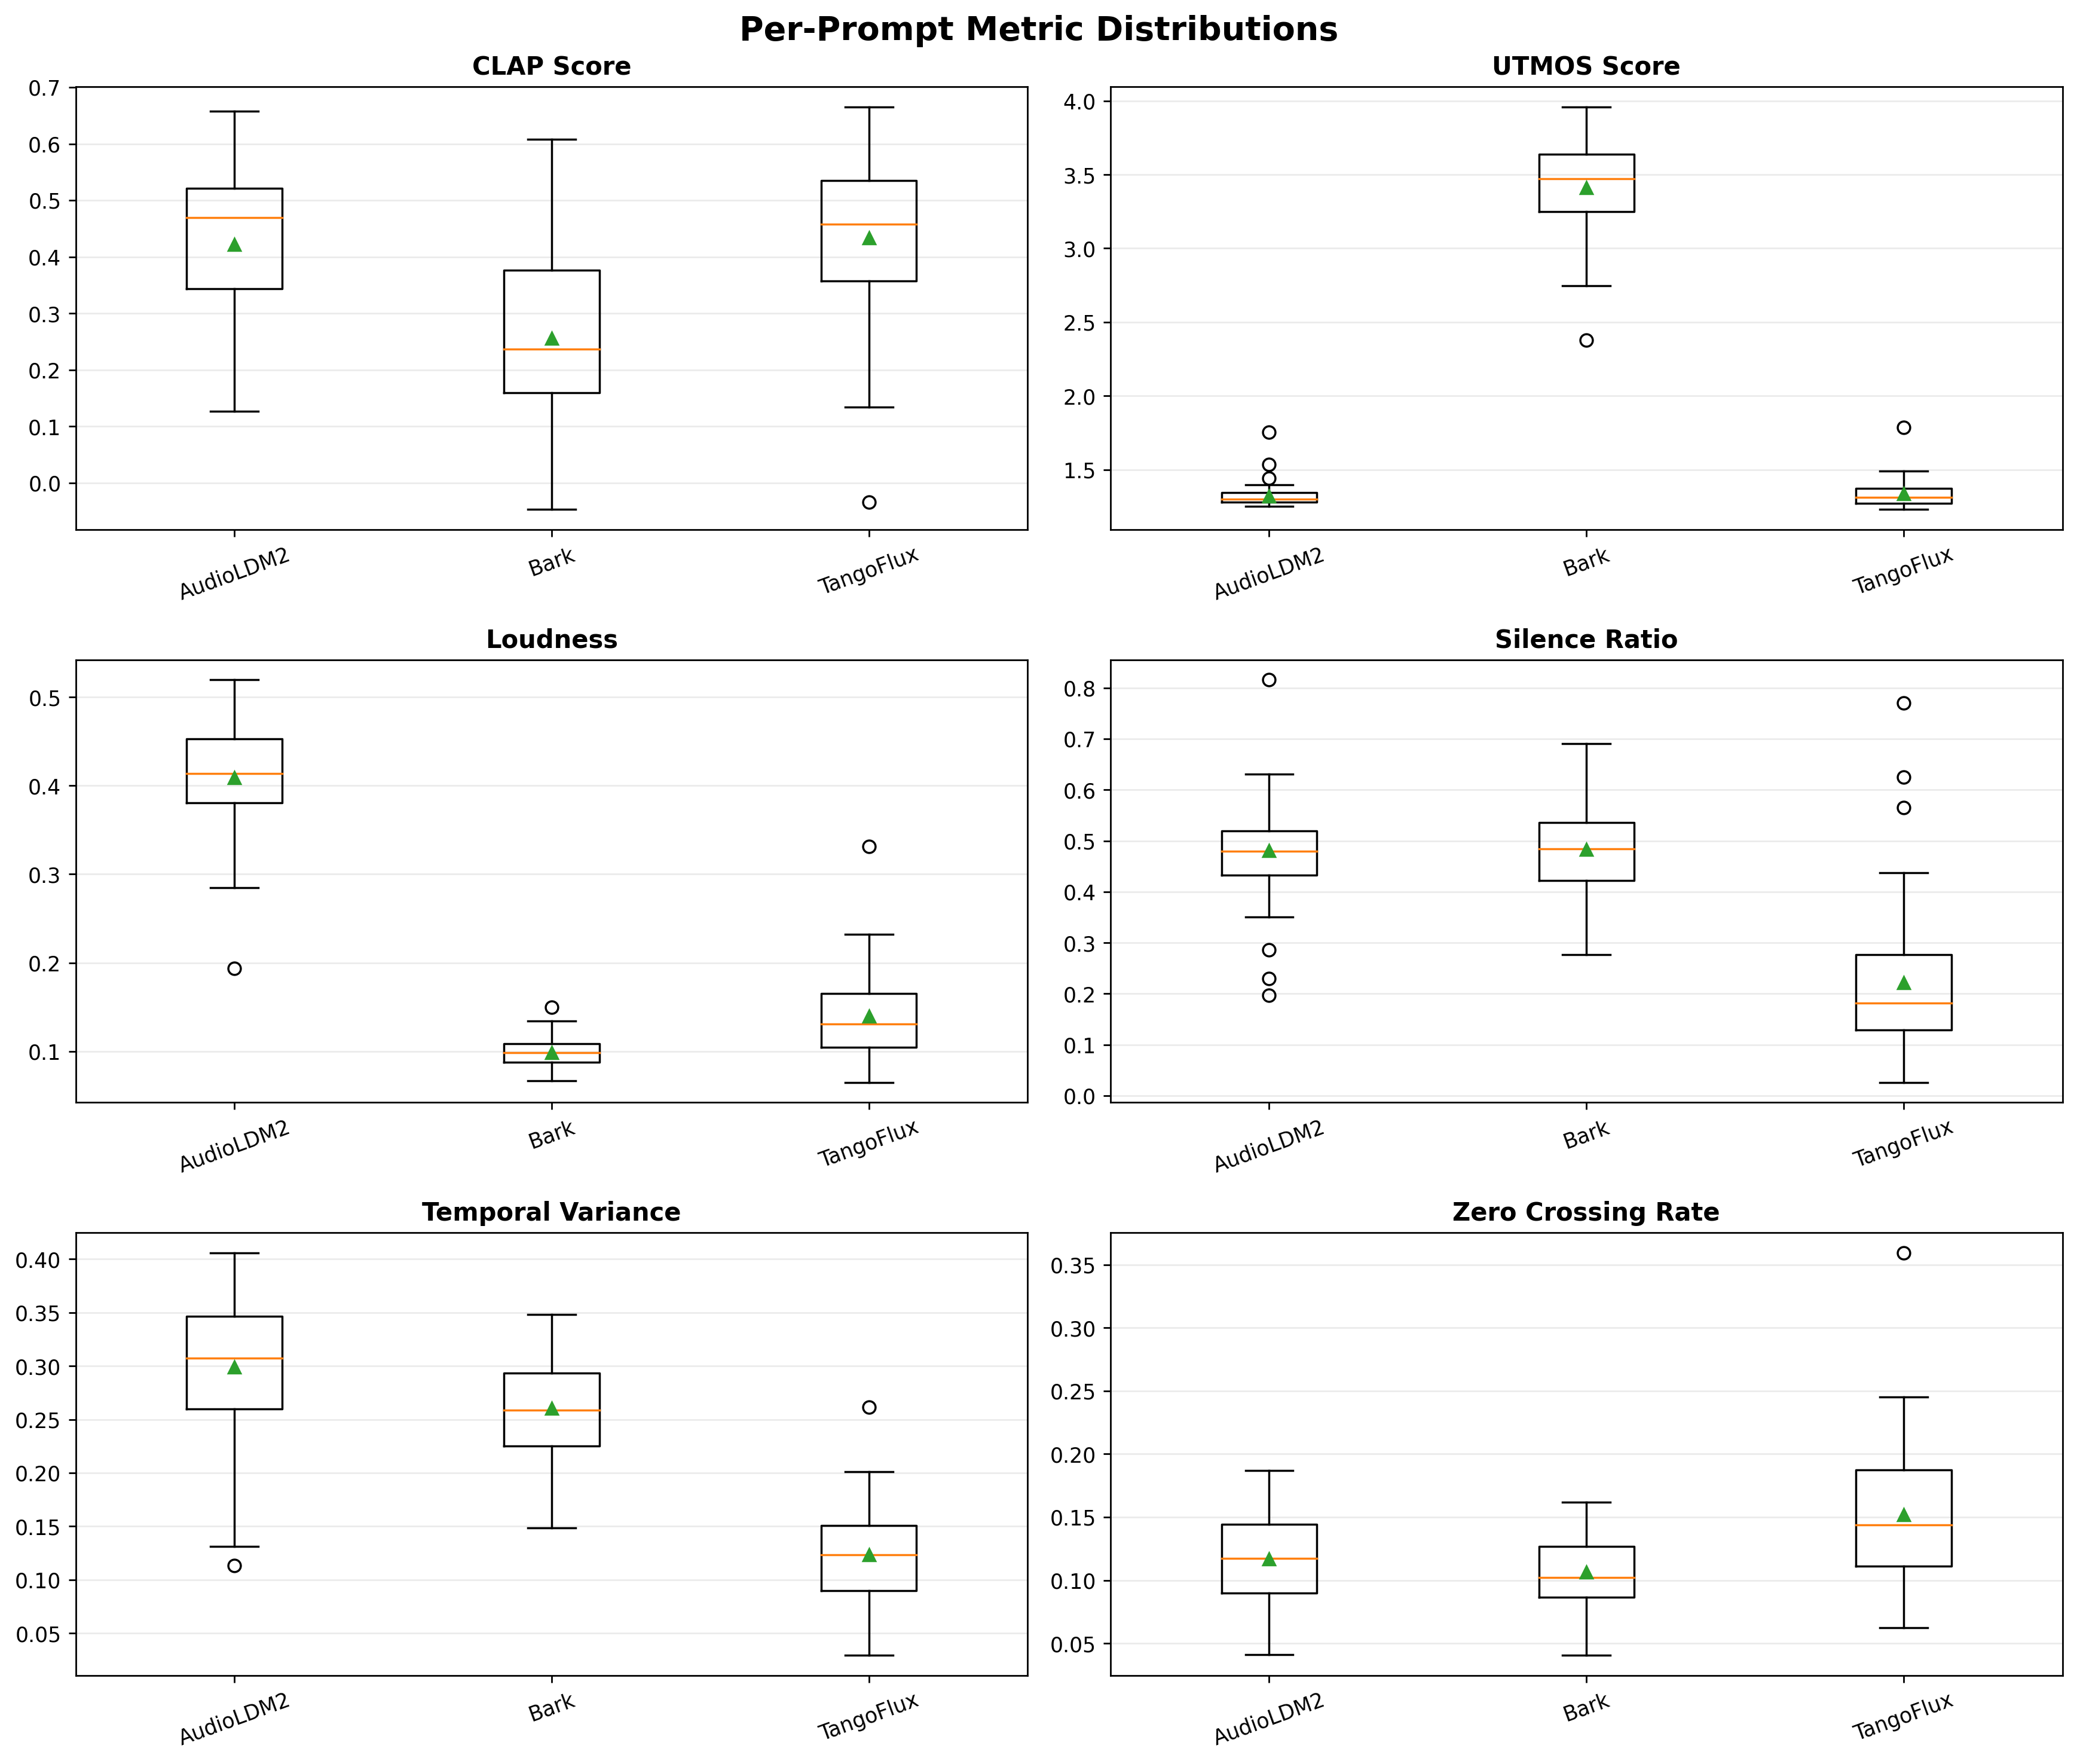

Saved: outputs\evaluation\metric_distributions.png


In [17]:
def plot_metric_distributions(results_df, metrics):
    available_metrics = [metric for metric in metrics if metric in results_df.columns and results_df[metric].notna().any()]
    if not available_metrics:
        print('No distribution metrics available.')
        return

    n_cols = 2
    n_rows = int(np.ceil(len(available_metrics) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = np.ravel([axes]) if len(available_metrics) == 1 else np.ravel(axes)

    for ax, metric in zip(axes, available_metrics):
        grouped = [(name, group[metric].dropna().values) for name, group in results_df.groupby('Model')]
        labels = [name for name, values in grouped if len(values) > 0]
        data = [values for name, values in grouped if len(values) > 0]

        ax.boxplot(data, labels=labels, showmeans=True)
        ax.set_title(metric, weight='bold')
        ax.grid(axis='y', alpha=0.25)
        ax.tick_params(axis='x', rotation=20)

    for ax in axes[len(available_metrics):]:
        ax.axis('off')

    fig.suptitle('Per-Prompt Metric Distributions', fontsize=16, weight='bold')
    fig.tight_layout()
    save_path = EVAL_DIR / 'metric_distributions.png'
    fig.savefig(save_path, dpi=250, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=str(save_path)))
    print(f'Saved: {save_path}')

plot_metric_distributions(results_df, ['CLAP Score', 'UTMOS Score', 'Loudness', 'Silence Ratio', 'Temporal Variance', 'Zero Crossing Rate'])

## 9. Mel Spectrogram Comparison

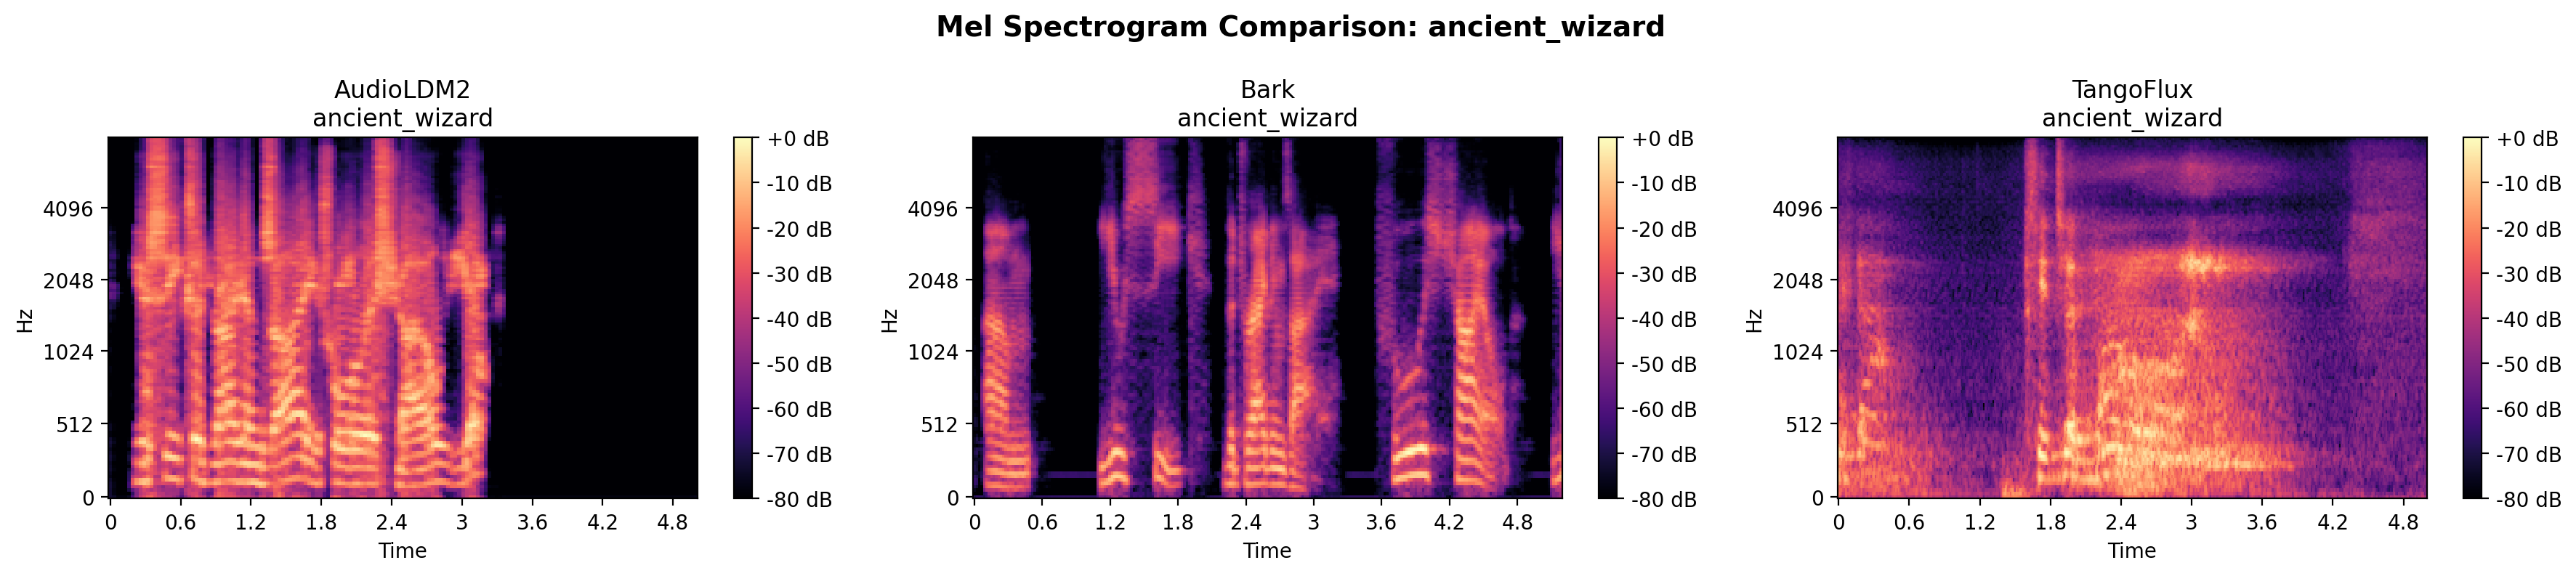

Saved: outputs\evaluation\mel_spectrogram_ancient_wizard.png


In [18]:
def plot_mel_spectrograms(test_id='ancient_wizard', model_names=None):
    if model_names is None:
        model_names = MODEL_NAMES

    audio_files = []
    for model_name in model_names:
        wav_path = OUTPUT_DIR / model_name / f'{test_id}.wav'
        if wav_path.exists():
            audio_files.append((model_name, wav_path))
        else:
            print(f'Missing: {wav_path}')

    if not audio_files:
        print(f'No files found for {test_id}.')
        return

    fig, axes = plt.subplots(1, len(audio_files), figsize=(6 * len(audio_files), 4))
    if len(audio_files) == 1:
        axes = [axes]

    for ax, item in zip(axes, audio_files):
        model_name, audio_path = item
        audio, sr = librosa.load(audio_path, sr=None, mono=True)
        mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128, fmax=8000)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        img = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', fmax=8000, ax=ax)
        ax.set_title(f'{model_name}\n{test_id}', fontsize=12)
        fig.colorbar(img, ax=ax, format='%+2.0f dB')

    fig.suptitle(f'Mel Spectrogram Comparison: {test_id}', fontsize=14, weight='bold')
    fig.tight_layout()
    save_path = EVAL_DIR / f'mel_spectrogram_{test_id}.png'
    fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=str(save_path)))
    print(f'Saved: {save_path}')

plot_mel_spectrograms('ancient_wizard')

## 10. Listen to One Prompt Across Models

In [19]:
def listen_to_prompt(test_id='ancient_wizard', model_names=None):
    if model_names is None:
        model_names = MODEL_NAMES

    for model_name in model_names:
        wav_path = OUTPUT_DIR / model_name / f'{test_id}.wav'
        if wav_path.exists():
            print(model_name)
            display(Audio(filename=str(wav_path)))
        else:
            print(f'Missing: {wav_path}')

listen_to_prompt('ancient_wizard')

AudioLDM2


Bark


TangoFlux


## 11. Saved Outputs

In [20]:
print('Evaluation files:')
for filepath in sorted(EVAL_DIR.glob('*')):
    print(filepath)

Evaluation files:
outputs\evaluation\audio_metrics.csv
outputs\evaluation\clap_scores.csv
outputs\evaluation\comparison_summary.csv
outputs\evaluation\evaluation_results.csv
outputs\evaluation\evaluation_results.json
outputs\evaluation\generated_audio_index.csv
outputs\evaluation\mel_spectrogram_ancient_wizard.png
outputs\evaluation\metric_distributions.png
outputs\evaluation\utmos_scores.csv
outputs\evaluation\win_rates.csv
